## Import Packages

In [1]:
import pandas as pd
import glob
import os
import numpy as np
import seaborn as sns
import plotly.express as px
import dash_bio
from matplotlib import cm, colors
import matplotlib.pyplot as plt
from math import sin, cos, pi
from itertools import cycle
import random


## Read GCT files

In [2]:
path = 'gct_files/2025-08-28/**/*_ssGSEA-combined.gct'
path = os.path.normpath(path)
wd = os.getcwd()

In [3]:
wd_path = os.path.join(wd, path) 

In [4]:
wd_path

'C:\\Users\\Fredrik\\Documents\\Heim_lab\\Marie_Anne\\biopsy_vs_resection\\phospho_proteomics\\gct_files\\2025-08-28\\**\\*_ssGSEA-combined.gct'

In [5]:
def extract_fdr(path, title):
    df = pd.read_csv(str(path), sep='\t', skiprows=2)
    df.columns = df.columns.str.replace('ResectionvsBiopsy', title + '_ResectionvsBiopsy')
    df = df.set_index('id')
    #print(df.columns)
    return df.iloc[:,np.r_[1,2,6,7]]

In [6]:
df_list = []
for name in glob.glob(path, recursive=True):
    #print(name.split('\\')[-1].split('_')[0])
    df_list.append(extract_fdr(os.path.join(wd, name), title=name.split('\\')[-1].split('_')[0]))

df_gct = pd.concat(df_list, join='outer', axis=1)

In [7]:
df_gct.shape

(127, 8)

In [8]:
df_list[0].shape

(127, 4)

In [9]:
df_gct.head()

,Signature.set.size,Signature.set.overlap.percent.HCC_ResectionvsBiopsy_adj_pval,fdr.pvalue.HCC_ResectionvsBiopsy_adj_pval,HCC_ResectionvsBiopsy_adj_pval,Signature.set.size,Signature.set.overlap.percent.Liver_ResectionvsBiopsy_adj_pval,fdr.pvalue.Liver_ResectionvsBiopsy_adj_pval,Liver_ResectionvsBiopsy_adj_pval
id,,,,,,,,
PERT-P100-DIA2_ZEBULARINE,133,10.5,0.225778,2.2232,133.0,7.5,0.455025,1.7528
PERT-P100-DIA2_VX-970,175,11.4,0.931291,-0.2690,NaN,NaN,NaN,NaN
PERT-P100-DIA2_VU0155056,110,10.9,0.898300,0.4163,NaN,NaN,NaN,NaN
PERT-P100-DIA2_VORINOSTAT,556,7.6,0.586475,1.3254,556.0,4.3,0.755754,-1.0056
PERT-P100-DIA2_VERTEPORFIN,195,8.2,0.986190,0.0529,195.0,7.2,0.455025,-1.7713


## Create column with set size

In [10]:
df_gct['set_size'] = df_gct['Signature.set.size'].max(axis=1).astype('int')
df_gct = df_gct.drop('Signature.set.size', axis=1)

In [11]:
df_gct.set_size.isna().sum()

0

In [12]:
df_gct.columns

Index(['Signature.set.overlap.percent.HCC_ResectionvsBiopsy_adj_pval',
       'fdr.pvalue.HCC_ResectionvsBiopsy_adj_pval',
       'HCC_ResectionvsBiopsy_adj_pval',
       'Signature.set.overlap.percent.Liver_ResectionvsBiopsy_adj_pval',
       'fdr.pvalue.Liver_ResectionvsBiopsy_adj_pval',
       'Liver_ResectionvsBiopsy_adj_pval', 'set_size'],
      dtype='object')

In [13]:
df_gct.head()

,Signature.set.overlap.percent.HCC_ResectionvsBiopsy_adj_pval,fdr.pvalue.HCC_ResectionvsBiopsy_adj_pval,HCC_ResectionvsBiopsy_adj_pval,Signature.set.overlap.percent.Liver_ResectionvsBiopsy_adj_pval,fdr.pvalue.Liver_ResectionvsBiopsy_adj_pval,Liver_ResectionvsBiopsy_adj_pval,set_size
id,,,,,,,
PERT-P100-DIA2_ZEBULARINE,10.5,0.225778,2.2232,7.5,0.455025,1.7528,133
PERT-P100-DIA2_VX-970,11.4,0.931291,-0.2690,NaN,NaN,NaN,175
PERT-P100-DIA2_VU0155056,10.9,0.898300,0.4163,NaN,NaN,NaN,110
PERT-P100-DIA2_VORINOSTAT,7.6,0.586475,1.3254,4.3,0.755754,-1.0056,556
PERT-P100-DIA2_VERTEPORFIN,8.2,0.986190,0.0529,7.2,0.455025,-1.7713,195


In [14]:
# fdr_col, overlap_col, nes_col = [], [], []

# for d in dfs:
#     for col in d.columns:
#         if 'overlap' in col:
#             overlap_col.append(col)
#         elif col.startswith('fdr'):
#             fdr_col.append(col)
#         elif 'pval' in col:
#             nes_col.append(col)

In [15]:
df_gct.head()

,Signature.set.overlap.percent.HCC_ResectionvsBiopsy_adj_pval,fdr.pvalue.HCC_ResectionvsBiopsy_adj_pval,HCC_ResectionvsBiopsy_adj_pval,Signature.set.overlap.percent.Liver_ResectionvsBiopsy_adj_pval,fdr.pvalue.Liver_ResectionvsBiopsy_adj_pval,Liver_ResectionvsBiopsy_adj_pval,set_size
id,,,,,,,
PERT-P100-DIA2_ZEBULARINE,10.5,0.225778,2.2232,7.5,0.455025,1.7528,133
PERT-P100-DIA2_VX-970,11.4,0.931291,-0.2690,NaN,NaN,NaN,175
PERT-P100-DIA2_VU0155056,10.9,0.898300,0.4163,NaN,NaN,NaN,110
PERT-P100-DIA2_VORINOSTAT,7.6,0.586475,1.3254,4.3,0.755754,-1.0056,556
PERT-P100-DIA2_VERTEPORFIN,8.2,0.986190,0.0529,7.2,0.455025,-1.7713,195


In [16]:
def calc_overlap(df, overlap_col_name, label):
    df_n = df.copy()
    title = label + '_set_size'
    df_n[title] = df_n.loc[:,overlap_col_name].mul((df_n.loc[:,'set_size'] / 100), axis=0)
    df_n[title].fillna(0, inplace=True)
    #print(df_n[title])
    df_n[title] = df_n[title].astype('int')
    return df_n[title]

In [17]:
for tissue in ['Liver', 'HCC']:
    overlap_col = [col for col in df_gct.columns if tissue in col and 'overlap' in col]
    #print(overlap_col)
    df_gct[tissue + '_set_size'] = calc_overlap(df_gct, overlap_col, tissue)

In [18]:
df_gct.columns

Index(['Signature.set.overlap.percent.HCC_ResectionvsBiopsy_adj_pval',
       'fdr.pvalue.HCC_ResectionvsBiopsy_adj_pval',
       'HCC_ResectionvsBiopsy_adj_pval',
       'Signature.set.overlap.percent.Liver_ResectionvsBiopsy_adj_pval',
       'fdr.pvalue.Liver_ResectionvsBiopsy_adj_pval',
       'Liver_ResectionvsBiopsy_adj_pval', 'set_size', 'Liver_set_size',
       'HCC_set_size'],
      dtype='object')

In [19]:
df_gct.head()

,Signature.set.overlap.percent.HCC_ResectionvsBiopsy_adj_pval,fdr.pvalue.HCC_ResectionvsBiopsy_adj_pval,HCC_ResectionvsBiopsy_adj_pval,Signature.set.overlap.percent.Liver_ResectionvsBiopsy_adj_pval,fdr.pvalue.Liver_ResectionvsBiopsy_adj_pval,Liver_ResectionvsBiopsy_adj_pval,set_size,Liver_set_size,HCC_set_size
id,,,,,,,,,
PERT-P100-DIA2_ZEBULARINE,10.5,0.225778,2.2232,7.5,0.455025,1.7528,133,9,13
PERT-P100-DIA2_VX-970,11.4,0.931291,-0.2690,NaN,NaN,NaN,175,0,19
PERT-P100-DIA2_VU0155056,10.9,0.898300,0.4163,NaN,NaN,NaN,110,0,11
PERT-P100-DIA2_VORINOSTAT,7.6,0.586475,1.3254,4.3,0.755754,-1.0056,556,23,42
PERT-P100-DIA2_VERTEPORFIN,8.2,0.986190,0.0529,7.2,0.455025,-1.7713,195,14,15


## Change Column names

In [20]:
col_names = {}
for col in df_gct.columns:
    if col.startswith('fdr'):
        string = col.split('_')[0][11:] + '_' + col.split('_')[-2] + '_fdr'
        col_names[col] = string
    elif col.endswith('pval'):
        string = col.split('_')[0] + '_' + col.split('_')[-2] + '_NES'
        col_names[col] = string
print(col_names)
df_gct_n = df_gct.rename(col_names, axis=1) 

{'Signature.set.overlap.percent.HCC_ResectionvsBiopsy_adj_pval': 'Signature.set.overlap.percent.HCC_adj_NES', 'fdr.pvalue.HCC_ResectionvsBiopsy_adj_pval': 'HCC_adj_fdr', 'HCC_ResectionvsBiopsy_adj_pval': 'HCC_adj_NES', 'Signature.set.overlap.percent.Liver_ResectionvsBiopsy_adj_pval': 'Signature.set.overlap.percent.Liver_adj_NES', 'fdr.pvalue.Liver_ResectionvsBiopsy_adj_pval': 'Liver_adj_fdr', 'Liver_ResectionvsBiopsy_adj_pval': 'Liver_adj_NES'}


In [21]:
df_gct_n.columns

Index(['Signature.set.overlap.percent.HCC_adj_NES', 'HCC_adj_fdr',
       'HCC_adj_NES', 'Signature.set.overlap.percent.Liver_adj_NES',
       'Liver_adj_fdr', 'Liver_adj_NES', 'set_size', 'Liver_set_size',
       'HCC_set_size'],
      dtype='object')

In [24]:
df_gct_n.to_csv('PTMsigDB_output_28082025.csv')

## Create Row Color with Overlap %

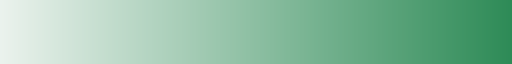

In [25]:
sns.light_palette("seagreen", as_cmap=True)

In [26]:
# Map overlap max % to color
# First normalize color data to 0-100%
norm = colors.Normalize(vmin=0, vmax=100, clip=True)
mapper = cm.ScalarMappable(norm=norm, cmap=sns.light_palette("seagreen", as_cmap=True))

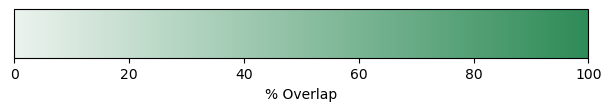

In [27]:
fig, ax = plt.subplots(figsize=(6, 1), layout='constrained')

fig.colorbar(mapper,
             cax=ax, orientation='horizontal', label='% Overlap')

plt.savefig('Overlap_colorbar.pdf', bbox_inches='tight')

In [28]:
mapper.to_rgba(df_gct_n['Liver_set_size'])

array([[0.85461937, 0.91458212, 0.87712314, 1.        ],
       [0.92146086, 0.95121201, 0.93025578, 1.        ],
       [0.92146086, 0.95121201, 0.93025578, 1.        ],
       [0.75290406, 0.85884099, 0.79626911, 1.        ],
       [0.81974555, 0.89547088, 0.84940176, 1.        ],
       [0.82555785, 0.89865608, 0.85402199, 1.        ],
       [0.92146086, 0.95121201, 0.93025578, 1.        ],
       [0.81974555, 0.89547088, 0.84940176, 1.        ],
       [0.92146086, 0.95121201, 0.93025578, 1.        ],
       [0.92146086, 0.95121201, 0.93025578, 1.        ],
       [0.84880707, 0.91139692, 0.87250291, 1.        ],
       [0.77324712, 0.86998922, 0.81243992, 1.        ],
       [0.92146086, 0.95121201, 0.93025578, 1.        ],
       [0.92146086, 0.95121201, 0.93025578, 1.        ],
       [0.92146086, 0.95121201, 0.93025578, 1.        ],
       [0.92146086, 0.95121201, 0.93025578, 1.        ],
       [0.92146086, 0.95121201, 0.93025578, 1.        ],
       [0.84008861, 0.9066191 ,

## Plot Results


In [29]:
df_gct_liver = df_gct_n.loc[:,[col for col in df_gct_n.columns if 'Liver' in col]].copy()
df_gct_hcc = df_gct_n.loc[:,[col for col in df_gct_n.columns if 'HCC' in col]].copy()

df_gct_liver = df_gct_liver.dropna(how='all')
df_gct_hcc = df_gct_hcc.dropna(how='all')

df_gct_liver['set_size'] = df_gct_n['set_size']
df_gct_hcc['set_size'] = df_gct_n['set_size']

In [30]:
df_gct_liver.head()

,Signature.set.overlap.percent.Liver_adj_NES,Liver_adj_fdr,Liver_adj_NES,Liver_set_size,set_size
id,,,,,
PERT-P100-DIA2_ZEBULARINE,7.5,0.455025,1.7528,9,133
PERT-P100-DIA2_VX-970,NaN,NaN,NaN,0,175
PERT-P100-DIA2_VU0155056,NaN,NaN,NaN,0,110
PERT-P100-DIA2_VORINOSTAT,4.3,0.755754,-1.0056,23,556
PERT-P100-DIA2_VERTEPORFIN,7.2,0.455025,-1.7713,14,195


In [31]:
# Export table 5% fdr
df_sig = df_gct_n[df_gct_n.loc[:,['Liver_adj_fdr', 'HCC_adj_fdr']] < 0.05].any(axis=1)
df_sig = df_gct_n[df_sig]
#df_sig.to_csv('GCT_output_0.05fdr.csv')

In [32]:
df_sig.shape

(24, 9)

In [33]:
df_sig.head()

,Signature.set.overlap.percent.HCC_adj_NES,HCC_adj_fdr,HCC_adj_NES,Signature.set.overlap.percent.Liver_adj_NES,Liver_adj_fdr,Liver_adj_NES,set_size,Liver_set_size,HCC_set_size
id,,,,,,,,,
PERT-P100-DIA2_TRETINOIN,16.0,0.425533,1.8057,8.9,0.015667,3.8251,225,20,36
PERT-P100-DIA2_SMER-3,15.3,0.015875,4.2696,12.1,0.630307,1.3143,157,18,24
PERT-P100-DIA2_SIROLIMUS,10.0,0.043463,3.2621,NaN,NaN,NaN,100,0,10
PERT-P100-DIA2_SEMAGACESTAT,16.3,0.015875,5.6794,10.1,0.778605,0.9505,178,17,29
PERT-P100-DIA2_ROLIPRAM,13.4,0.048092,3.0869,7.3,0.061801,3.2141,164,11,21


In [34]:
df_sig.reset_index(inplace=True)

In [35]:
df_sig_path = df_sig[df_sig.id.str.startswith('PATH-')]
df_sig_path = df_sig_path.set_index('id')

In [36]:
df_sig_path.columns

Index(['Signature.set.overlap.percent.HCC_adj_NES', 'HCC_adj_fdr',
       'HCC_adj_NES', 'Signature.set.overlap.percent.Liver_adj_NES',
       'Liver_adj_fdr', 'Liver_adj_NES', 'set_size', 'Liver_set_size',
       'HCC_set_size'],
      dtype='object')

In [37]:
df_sig_path.shape

(1, 9)

In [38]:
df_sig_path['set_label'] = df_sig_path[['Liver_set_size', 'HCC_set_size']].max(axis=1).astype('str').str.cat(df_sig_path['set_size'].astype('str'), sep='/')
print(df_sig_path['set_label'])

id
PATH-BI_ISCHEMIA    34/162
Name: set_label, dtype: object


In [39]:
row_col_df = pd.DataFrame(mapper.to_rgba(df_sig_path[['Liver_set_size', 'HCC_set_size']].max(axis=1)))
row_col_df.set_index(df_sig_path.index)
df_sig_path['Overlap'] = mapper.to_rgba(df_sig_path[['Liver_set_size', 'HCC_set_size']].max(axis=1)).tolist()

In [40]:
df_sig_path.columns

Index(['Signature.set.overlap.percent.HCC_adj_NES', 'HCC_adj_fdr',
       'HCC_adj_NES', 'Signature.set.overlap.percent.Liver_adj_NES',
       'Liver_adj_fdr', 'Liver_adj_NES', 'set_size', 'Liver_set_size',
       'HCC_set_size', 'set_label', 'Overlap'],
      dtype='object')

In [64]:
#annot_sig = pd.DataFrame().reindex_like(df_sig_path[fdr_col])
annot_sig = pd.DataFrame(np.where(df_sig_path[['Liver_adj_fdr', 'HCC_adj_fdr']] < 0.05, '*', ''), index=df_sig_path.index, columns=df_sig_path[['Liver_adj_NES', 'HCC_adj_NES']].columns)

In [65]:
annot_sig

,Liver_adj_NES,HCC_adj_NES
id,,
PATH-BI_ISCHEMIA,*,*


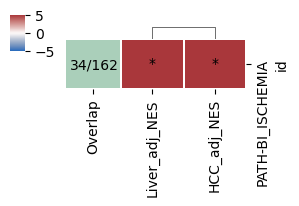

In [73]:
# clustermap of pathways with missing values replace with 0 significant in at least one

ax = sns.clustermap(df_sig_path[['Liver_adj_NES', 'HCC_adj_NES']],
               cmap=sns.color_palette("vlag", as_cmap=True),
               yticklabels=True,
               xticklabels=True,
              row_colors=df_sig_path['Overlap'],
                row_cluster=False,
                colors_ratio=0.25,
                   figsize=(3,2),
                   vmin=-5, vmax=5,
                   annot=annot_sig,
                   fmt = '',
                   annot_kws={'color':'black'},
                   linewidths=0.1)
#df_sig_path['cluster_index'] = ax.dendrogram_row.reordered_ind
#resorted_df = df_sig_path.set_index('cluster_index')
#print(df_sig_path)
# 24h
# for idx, name in enumerate(df_sig_path['set_label'] ):
#     plt.annotate(name, xy=(2.8,(-5.2-(4.2*idx))), annotation_clip=False )

# 4h
for idx, name in enumerate(df_sig_path['set_label'] ):
    plt.annotate(name, xy=(4,(-10-(11.5*idx))), annotation_clip=False )


# Reverse colors
#cmap=sns.cm.rocket_r
plt.savefig('PTMsigDB_pathway_biopsy_res_280825.pdf', bbox_inches='tight', dpi=300)

In [85]:
# Kinase
df_sig_k = df_sig[df_sig.id.str.startswith('KINASE-')]
df_sig_k = df_sig_k.set_index('id')

df_sig_k['set_label'] = df_sig_k[['Liver_set_size',
                                        'HCC_set_size']].max(axis=1).astype('str')\
                                        .str.cat(df_sig_k['set_size'].astype('str'), sep='/')
print(df_sig_k['set_label'])

df_sig_k['Overlap'] = mapper.to_rgba(df_sig_k[['Signature.set.overlap.percent.Liver_adj_NES',
                                                     'Signature.set.overlap.percent.HCC_adj_NES']].max(axis=1)).tolist()

#annot_sig = pd.DataFrame().reindex_like(df_sig_path[fdr_col])
annot_sig = pd.DataFrame(np.where(df_sig_k[['Liver_adj_fdr', 'HCC_adj_fdr']] < 0.05, '*', ''),
                         index=df_sig_k.index, columns=df_sig_k[['Liver_adj_NES', 'HCC_adj_NES']].columns)

id
KINASE-iKiP_MAPK14    10/294
KINASE-iKiP_MAPK13    12/413
KINASE-iKiP_AMPKA1     11/88
Name: set_label, dtype: object


In [90]:
df_sig.sort_values('Liver_adj_fdr')

,id,Signature.set.overlap.percent.HCC_adj_NES,HCC_adj_fdr,HCC_adj_NES,Signature.set.overlap.percent.Liver_adj_NES,Liver_adj_fdr,Liver_adj_NES,set_size,Liver_set_size,HCC_set_size
0,PERT-P100-DIA2_TRETINOIN,16.0,0.425533,1.8057,8.9,0.015667,3.8251,225,20,36
13,PERT-P100-DIA2_EPZ-5687,17.6,0.048106,2.9803,11.1,0.015667,4.0553,108,11,19
20,PATH-BI_ISCHEMIA,21.6,0.015875,5.7499,14.8,0.015667,6.6307,162,23,34
18,PERT-P100-DIA2_BAFILOMYCIN_A1,26.7,0.275284,2.0230,14.7,0.025768,3.2987,75,11,20
4,PERT-P100-DIA2_ROLIPRAM,13.4,0.048092,3.0869,7.3,0.061801,3.2141,164,11,21
15,PERT-P100-DIA2_COMPOUND_E,10.8,0.037956,3.6133,5.2,0.061801,2.9100,194,10,20
11,PERT-P100-DIA2_GOSSYPETIN,21.9,0.048092,3.2011,11.6,0.079774,2.8085,155,17,33
1,PERT-P100-DIA2_SMER-3,15.3,0.015875,4.2696,12.1,0.630307,1.3143,157,18,24
3,PERT-P100-DIA2_SEMAGACESTAT,16.3,0.015875,5.6794,10.1,0.778605,0.9505,178,17,29
14,PERT-P100-DIA2_DASATINIB,7.8,0.037956,3.1745,5.2,0.778605,-0.8960,193,10,15


In [76]:
#df_sig_k = df_sig_k.fillna(0)

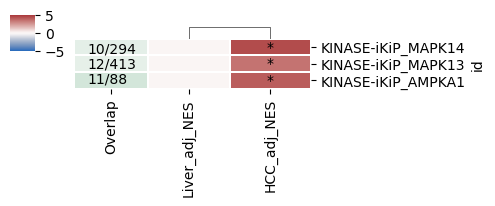

In [83]:
ax = sns.clustermap(df_sig_k[['Liver_adj_NES', 'HCC_adj_NES']],
               cmap=sns.color_palette("vlag", as_cmap=True),
               yticklabels=True,
               xticklabels=True,
              row_colors=df_sig_k['Overlap'],
                row_cluster=False,
                colors_ratio=0.25,
                   figsize=(5,2),
                   vmin=-5, vmax=5,
                   annot=annot_sig,
                   fmt = '',
                   annot_kws={'color':'black'},
                   linewidths=0.1)
#df_sig_path['cluster_index'] = ax.dendrogram_row.reordered_ind
#resorted_df = df_sig_path.set_index('cluster_index')
#print(df_sig_path)
# 24h
# for idx, name in enumerate(df_sig_path['set_label'] ):
#     plt.annotate(name, xy=(2.8,(-5.2-(4.2*idx))), annotation_clip=False )

# 4h
for idx, name in enumerate(df_sig_k['set_label'] ):
    plt.annotate(name, xy=(3.1,(-5.5-(4.2*idx))), annotation_clip=False )
    

plt.savefig('PTMsigDB_kinase_biopsy_res_280825.pdf', bbox_inches='tight', dpi=300)

In [84]:
df_sig_k

,Signature.set.overlap.percent.HCC_adj_NES,HCC_adj_fdr,HCC_adj_NES,Signature.set.overlap.percent.Liver_adj_NES,Liver_adj_fdr,Liver_adj_NES,set_size,Liver_set_size,HCC_set_size,set_label,Overlap
id,,,,,,,,,,,
KINASE-iKiP_MAPK14,3.7,0.015875,4.4599,0.0,0.0,0.0,294,0,10,10/294,"[0.8953054970293373, 0.9368785763524047, 0.909..."
KINASE-iKiP_MAPK13,3.1,0.037956,3.4729,0.0,0.0,0.0,413,0,12,12/413,"[0.9011178006079273, 0.9400637839714024, 0.914..."
KINASE-iKiP_AMPKA1,12.5,0.015875,4.0622,0.0,0.0,0.0,88,0,11,11/88,"[0.8284640058755501, 0.900248688733931, 0.8563..."
